In [1]:
import numpy as np
from sklearn.decomposition import PCA
import joblib

# Load original data
X_full = np.load("/Users/nithish/Downloads/yelp_original_flattened_X_train.npy")
X_full = X_full.astype(np.float32)

# Subsample only 20k images randomly
np.random.seed(42)
subset_idx = np.random.choice(X_full.shape[0], size=20000, replace=False)
X_subset = X_full[subset_idx]

# Fit PCA
pca = PCA(n_components=200, random_state=42)
pca.fit(X_subset)

# Save PCA model
joblib.dump(pca, "/Users/nithish/Downloads/pca_model.pkl")
print("✅ PCA model saved successfully!")


✅ PCA model saved successfully!


✅ Loaded PCA and kNN models


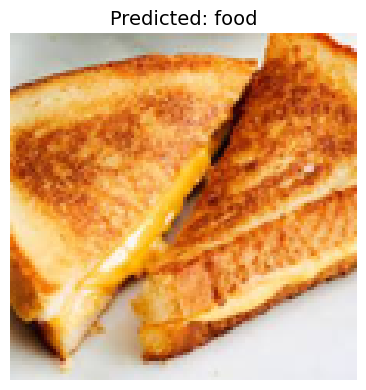


🎯 Predicted Label: food
📈 Class Probabilities:
   drink: 0.000
    food: 1.000
  inside: 0.000
    menu: 0.000
 outside: 0.000


In [10]:
import numpy as np
import joblib
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# === Step 1: Paths ===
image_path = "/Users/nithish/Downloads/test3.jpeg"  # your external image
pca_path = "/Users/nithish/Downloads/pca_model.pkl"
knn_path = "/Users/nithish/Downloads/final_knn_model_k3.pkl"
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
image_size = (112, 112)

# === Step 2: Load PCA and kNN model ===
pca = joblib.load(pca_path)
knn_model = joblib.load(knn_path)
print("✅ Loaded PCA and kNN models")

# === Step 3: Load and preprocess image ===
img = Image.open(image_path).convert("RGB").resize(image_size)
img_array = np.array(img)
flat_img = img_array.flatten().reshape(1, -1)

# === Step 4: PCA transform and prediction ===
img_pca = pca.transform(flat_img)
pred = knn_model.predict(img_pca)[0]
proba = knn_model.predict_proba(img_pca)[0]

# === Step 5: Show image with predicted label ===
plt.figure(figsize=(4, 4))
plt.imshow(img_array)
plt.title(f"Predicted: {class_names[pred]}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# === Step 6: Print Probabilities ===
print(f"\n🎯 Predicted Label: {class_names[pred]}")
print("📈 Class Probabilities:")
for i, p in enumerate(proba):
    print(f"{class_names[i]:>8}: {p:.3f}")
